# Worksheet 2: Root finding
## - 23MS121 
## - Manish Behera

### Q1. 
(8 points) Numerically estimate f ′(x) for f (x) = sin(x) at x = 2π/5, using
(a) Forward difference: f ′
n ≈ (fn+1 − fn)/h
(b) Backward difference: f ′
n ≈ (fn − fn−1)/h
(c) Central difference: f ′
n ≈ (fn+1 − fn−1)/(2h)
(d) Five-point approximation: f ′
n ≈ (fn−2 − 8fn−1 + 8fn+1 − fn+2)/(12h)
for h = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001].
(a) (3 points) Create a table to record the estimate derivatives using different methods for each h.
(b) (3 points) Plot the differences between exact values and the estimated values (the error).
(c) (2 points) Fit the log of the error versus the log of h and compare the efficiencies of the methods.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

In [2]:
def f(x):
    return np.sin(x)

In [3]:
def forward_diff(f,xn,h):
    return (f(xn+h) - f(xn))/h
def backward_diff(f,xn,h):
    return (f(xn) - f(xn-h))/h
def central_diff(f,xn,h):
    return (f(xn+h) - f(xn-h))/(2*h)
def five_point_approx(f,xn,h):
    return (f(xn-2*h)-8*f(xn-h)+8*f(xn+h)-f(xn+2*h))/(12*h)

In [4]:
#create a table to record the estimate derivatives using different methods for each h.
hs = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]

xn = 2*np.pi/5

exact = np.cos(xn)

forward_list = [forward_diff(f,xn,i) for i in hs]
backward_list = [backward_diff(f,xn,i) for i in hs]
central_list = [central_diff(f,xn,i) for i in hs]
five_point_list = [five_point_approx(f,xn,i) for i in hs]

tab = [forward_list,backward_list,central_list,five_point_list]

#print dataframe using pandas
column_names = [f'h={h}' for h in hs]
row_names = ["forward_diff","backward_diff","central_diff","five_point_approx"]

df = pd.DataFrame(tab, columns=column_names, index=row_names)
pd.set_option('display.precision', 6)
display(df)

,h=0.5,h=0.2,h=0.1,h=0.05,h=0.02,h=0.01,h=0.005,h=0.002,h=0.001,h=0.0005,h=0.0002,h=0.0001
forward_diff,0.063449,0.212172,0.260989,0.285117,0.299486,0.304257,0.306638,0.308066,0.308541,0.308779,0.308922,0.308969
backward_diff,0.529153,0.401750,0.356015,0.332660,0.318507,0.313767,0.311393,0.309968,0.309492,0.309255,0.309112,0.309065
central_diff,0.296301,0.306961,0.308502,0.308888,0.308996,0.309012,0.309016,0.309017,0.309017,0.309017,0.309017,0.309017
five_point_approx,0.308392,0.309001,0.309016,0.309017,0.309017,0.309017,0.309017,0.309017,0.309017,0.309017,0.309017,0.309017


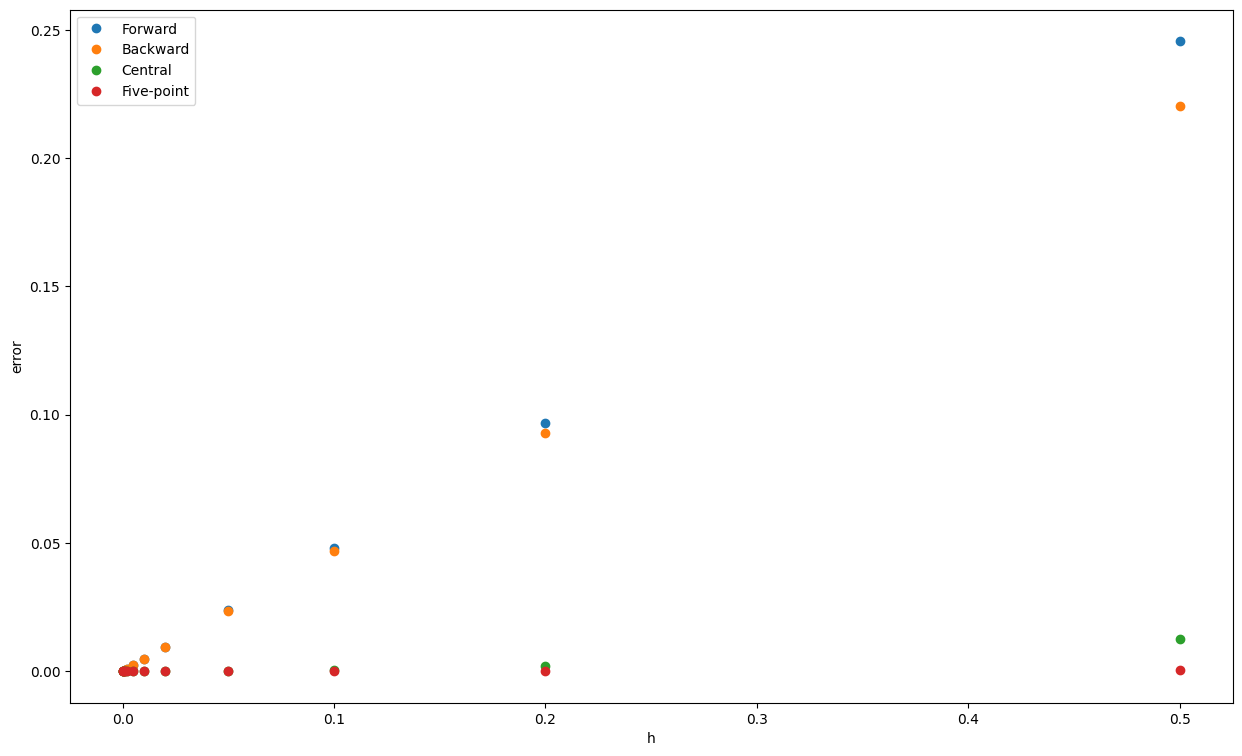

In [5]:
# plot the differences between exact values and the estimated values (the error).

calc_vals=[forward_list,backward_list,central_list,five_point_list]
descriptions = ["Forward","Backward","Central","Five-point"]
k = 0
plt.figure(figsize=(15, 9))
plt.xlabel("h")
plt.ylabel("error")
for vals in calc_vals:
    ys = [abs(i-exact) for i in vals]
    plt.plot(hs,ys,"o",label=descriptions[k])
    plt.legend()
    k += 1

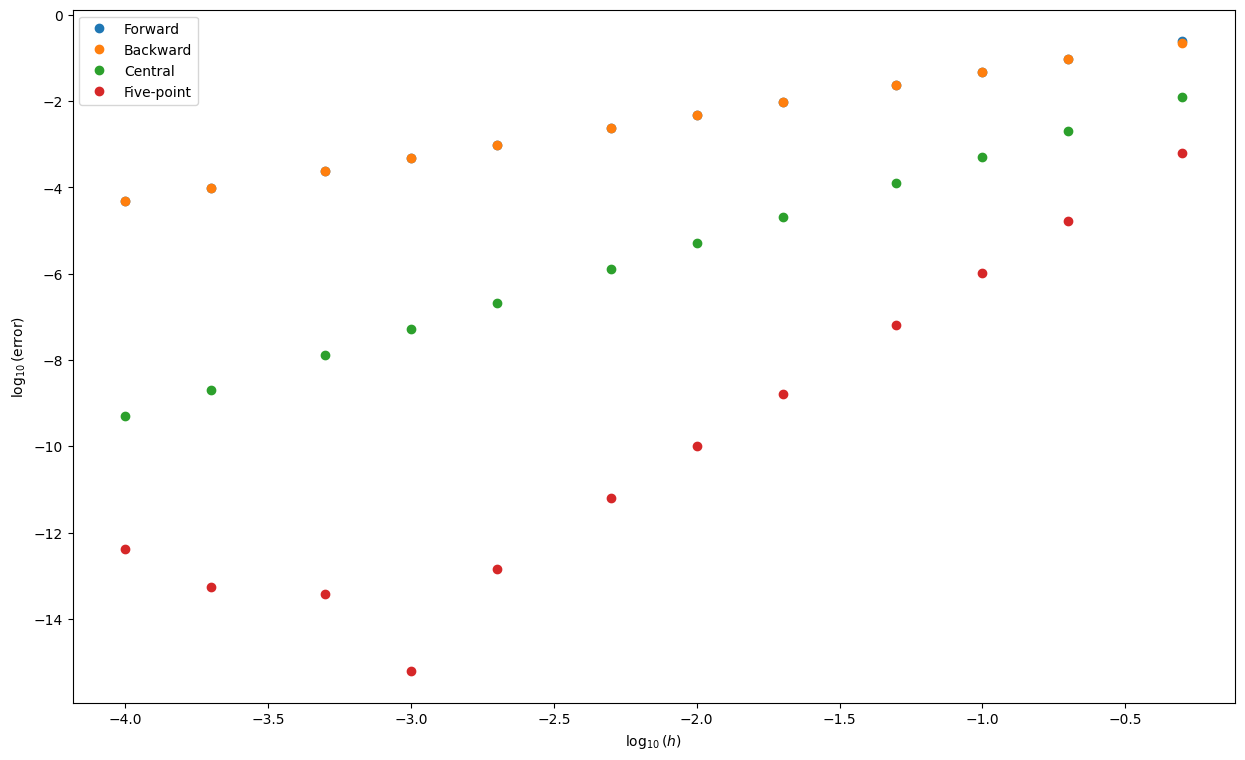

In [6]:
#fit the log of the error versus the log of h and compare the efficiencies of the methods.

descriptions = ["Forward","Backward","Central","Five-point"]
k = 0
plt.figure(figsize=(15, 9))
plt.xlabel(r'$\log_{10}(h)$')
plt.ylabel(r'$\log_{10}(\text{error})$')
for vals in calc_vals:
    ys = [abs(i-exact) for i in vals]
    plt.plot(np.log10(hs),np.log10(ys),"o",label=descriptions[k])
    plt.legend()
    k += 1

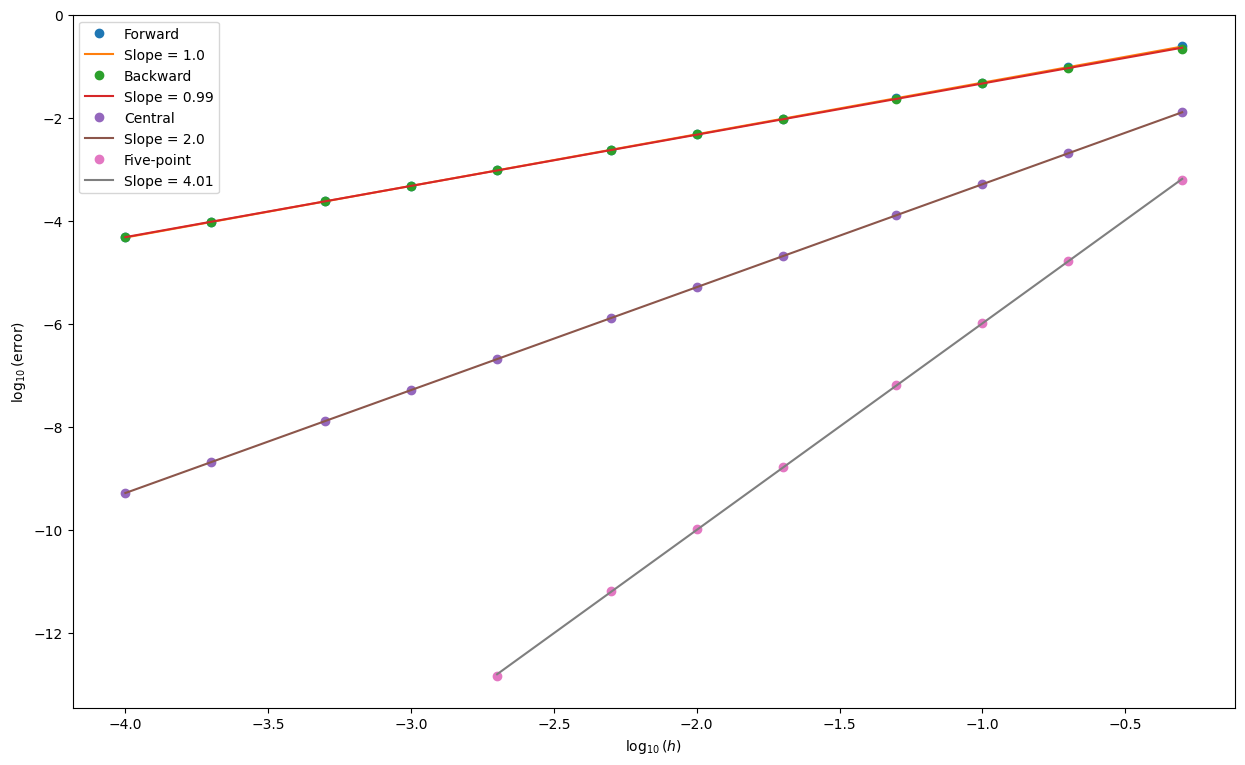

In [7]:
def eq_of_line(xs, p0, p1):
    return p0*xs+p1

k = 0
plt.figure(figsize=(15, 9))
plt.xlabel(r'$\log_{10}(h)$')
plt.ylabel(r'$\log_{10}(\text{error})$')
for vals in calc_vals:
    ys = np.log10([abs(i-exact) for i in vals])
    xs = np.log10(hs)
    if k==3:  # avoid fitting the rise in error in five-point
        numdata = 8
    else:
        numdata = len(hs)
    xs = xs[:numdata]
    ys = ys[:numdata]
    plt.plot(xs,ys,"o",label=descriptions[k])
    params, covariance = curve_fit(eq_of_line, xs, ys, p0=[1.0, 1.0]) #do not need covar_mat, need only params
    plt.plot(xs, eq_of_line(xs, params[0], params[1]),label="Slope = "+str(round(params[0],2))) #plt line
    plt.legend()
    k += 1

### Q2. 

(8 points) 
Numerically estimate R 10 f (x)dx for f (x) = ex, using the following methods:

(a) Linear (Trapezoidal): R x3
x1 f (x)dx = h
2 (f1 + 2f2 + f3) + O(h3)
(b) Quadratic (Simpson’s 1
3 rule): R x3
x1 f (x)dx = h
3 (f1 + 4f2 + f3) + O(h5)
(c) Cubic (Simpson’s 3
8 rule): R x4
x1 f (x)dx = 3h
8 (f1 + 3f2 + 3f3 + f4) + O(h5)
(d) Quartic (Boole’s rule): R x5
x1 f (x)dx = 2h
45 (7f1 + 32f2 + 12f3 + 32f4 + 7f5) + O(h7)

(a) (4 points) Consider the interval [0, 1). Choose m from [4, 8, 16, 32, 64]. For trapezoidal and

Simpson’s 1/3, N = 2m + 1. For Simpson’s 3/8, N = 3m + 1 and for Boole’s method N =
4m + 1. Create a table to record the estimate integral using different methods for each h =
(1.0 − 0.0)/(N − 1) value.
(b) (2 points) Plot the differences between exact values and the estimated values (the error).
(c) (2 points) Fit the log of the error versus the log of h and compare the efficiencies of the methods.

In [8]:
def f(x):
    return np.exp(x)

exact = np.exp(1)-1
print(exact)

1.718281828459045


In [9]:
range = [0,1] #definite integral bounds 
N = 10 #number of steps 
h = (range[1]-range[0])/N

##### Linear (Trapezoidal)

In [10]:
import numpy as np

def int_trap(f, x_min, x_max, N):
    h = (x_max - x_min) / N
    x = np.linspace(x_min, x_max, N + 1)
    y = f(x)
    # The sum of interior points (indices 1 to N-1) multiplied by 2, 
    # plus the endpoints (indices 0 and N) multiplied by 1.
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1]), h
print(int_trap(f,0,1,100))

(np.float64(1.7182961474504177), 0.01)


##### Quadratic (Simpson’s $\frac{1}{3}$ rule)

In [11]:
def int_simpson13(f,x_min,x_max,N):
    if N % 2 != 0: 
        print("N must be even")
        return None
        
    h = (x_max - x_min) / N
    x = np.linspace(x_min, x_max, N + 1)
    y = f(x)
    
    # 4 * sum of odd indx terms (y1, y3, ..., yN-1)
    sum_odd = np.sum(y[1:-1:2])
    # 2 * sum of even indx terms (y2, y4, ..., yN-2)
    sum_even = np.sum(y[2:-1:2])
    
    # Formula: (h/3) * [f(x0) + 4*sum_odd + 2*sum_even + f(xn)]
    return (h / 3) * (y[0] + y[-1] + 4 * sum_odd + 2 * sum_even), h
print(int_simpson13(f,0,1,100))

(np.float64(1.7182818285545045), 0.01)


#### Cubic (Simpson’s $\frac{3}{8}$ rule)

In [12]:
def int_simpson38(f,x_min,x_max,N):
    if N % 3 != 0:
        print("N must be a multiple of 3")
        return None
    
    h = (x_max - x_min) / N
    x = np.linspace(x_min, x_max, N + 1)
    y = f(x)

    internal_idx = np.arange(1, N)
    # Multiples of 3 get weight 2; all others get weight 3
    weights = np.where(internal_idx % 3 == 0, 2, 3)
    
    # Formula: (3h/8) * [f(x0) + f(xn) + sum(weights * internal_f_values)]
    total_sum = y[0] + y[-1] + np.sum(weights * y[1:-1])
    return (3 * h / 8) * total_sum, h
print(int_simpson38(f,0,1,300))

(np.float64(1.7182818284616974), 0.0033333333333333335)


#### Quartic (Boole’s rule)

In [13]:
def int_bool(f, x_min, x_max, N):
    if N % 4 != 0:
        print("N must be a multiple of 4")
        return None
    
    h = (x_max - x_min) / N
    x = np.linspace(x_min, x_max, N + 1)
    y = f(x)
    
    # weights: 
    # odd get 32
    # mid-segment get 12
    # segment boundaries get 14
    internal_idx = np.arange(1, N)
    weights = np.zeros(N - 1)
    
    weights[0::2] = 32
    weights[1::4] = 12     
    weights[3::4] = 14        
    total_sum = 7*y[0] + 7*y[-1] + np.sum(weights * y[1:-1])
    return (2 * h / 45) * total_sum, h
print(int_bool(f,0,1,100))

(np.float64(1.718281828459049), 0.01)


In [14]:
ms = [4, 8, 16, 32, 64]

# Number of points for each method
N_trap_s13 = [2*m + 1 for m in ms]  
N_s38 = [3*m + 1 for m in ms]       
N_B = [4*m + 1 for m in ms]        

trap_results, h_trap_s13 = zip(*[int_trap(f, 0, 1, N - 1) for N in N_trap_s13])
s13_results, h_trap_s13 = zip(*[int_simpson13(f, 0, 1, N - 1) for N in N_trap_s13])
s38_results, h_s38 = zip(*[int_simpson38(f, 0, 1, N - 1) for N in N_s38])
bool_results, h_B = zip(*[int_bool(f, 0, 1, N - 1) for N in N_B])

# DataFrame for display
data = {
    'm': ms,
    'N (Trap)': N_trap_s13,
    'h (Trap)': h_trap_s13,
    'Trapezoidal': trap_results,
    'N (S13)': N_trap_s13,
    'h (S13)': h_trap_s13,
    "Simpson 1/3": s13_results,
    'N (S38)': N_s38,
    'h (S38)': h_s38,
    "Simpson 3/8": s38_results,
    'N (Boole)': N_B,
    'h (Boole)': h_B,
    "Boole's": bool_results
}

df_results = pd.DataFrame(data)
pd.set_option('display.precision',6)
print(f"Exact value: {exact}")
display(df_results)

Exact value: 1.718281828459045


,m,N (Trap),h (Trap),Trapezoidal,N (S13),h (S13),Simpson 1/3,N (S38),h (S38),Simpson 3/8,N (Boole),h (Boole),Boole's
0,4,9,0.125000,1.720519,9,0.125000,1.718284,13,0.083333,1.718283,17,0.062500,1.718282
1,8,17,0.062500,1.718841,17,0.062500,1.718282,25,0.041667,1.718282,33,0.031250,1.718282
2,16,33,0.031250,1.718422,33,0.031250,1.718282,49,0.020833,1.718282,65,0.015625,1.718282
3,32,65,0.015625,1.718317,65,0.015625,1.718282,97,0.010417,1.718282,129,0.007812,1.718282
4,64,129,0.007812,1.718291,129,0.007812,1.718282,193,0.005208,1.718282,257,0.003906,1.718282


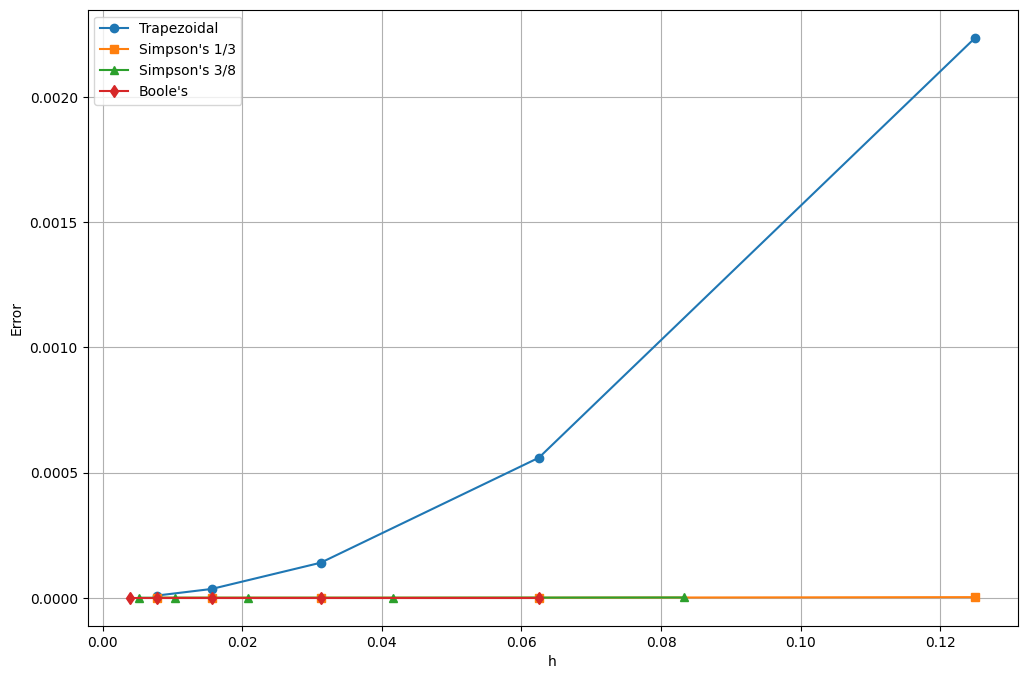

In [16]:
# (b) Plot the differences between exact values and the estimated values (the error)

trap_errors = [abs(val - exact) for val in trap_results]
s13_errors = [abs(val - exact) for val in s13_results]
s38_errors = [abs(val - exact) for val in s38_results]
bool_errors = [abs(val - exact) for val in bool_results]

plt.figure(figsize=(12, 8))
plt.plot(h_trap_s13, trap_errors, 'o-', label='Trapezoidal')
plt.plot(h_trap_s13, s13_errors, 's-', label="Simpson's 1/3")
plt.plot(h_s38, s38_errors, '^-', label="Simpson's 3/8")
plt.plot(h_B, bool_errors, 'd-', label="Boole's")
plt.xlabel('h')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

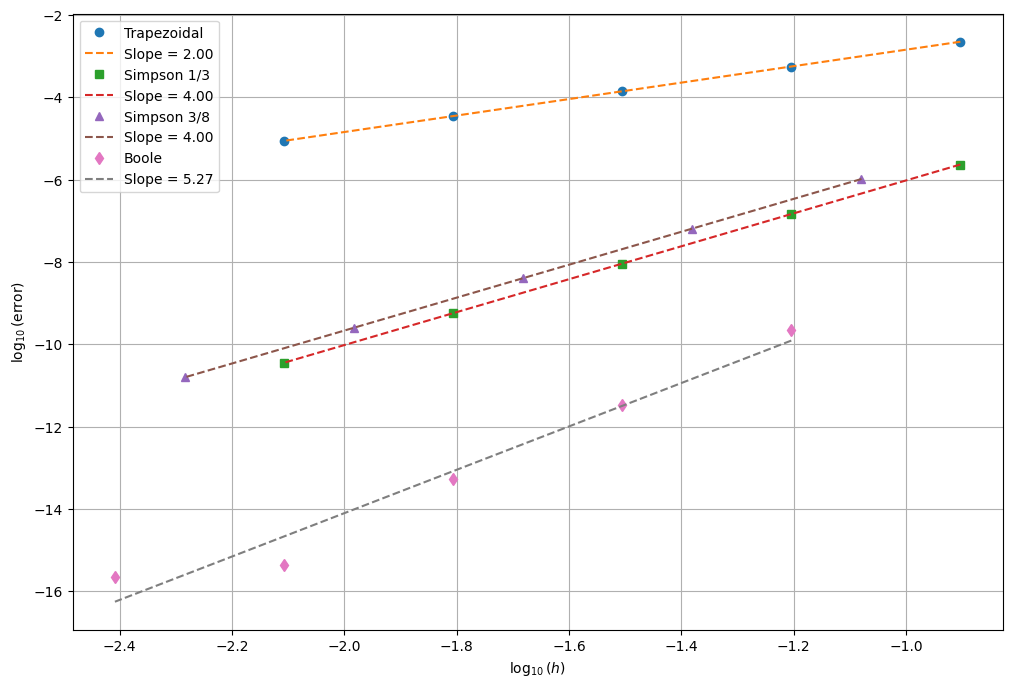

In [17]:
# (c) Fit the log of the error versus the log of h and compare the efficiencies of the methods

def eq_of_line(xs, p0, p1):
    return p0 * xs + p1

plt.figure(figsize=(12, 8))

# Data for fitting
methods = [
    ('Trapezoidal', h_trap_s13, trap_errors, 'o'),
    ("Simpson 1/3", h_trap_s13, s13_errors, 's'),
    ("Simpson 3/8", h_s38, s38_errors, '^'),
    ("Boole", h_B, bool_errors, 'd')
]

for name, h_vals, errors, marker in methods:
    log_h = np.log10(h_vals)
    log_err = np.log10(errors)
    
    plt.plot(log_h, log_err, marker, label=name)

    params, covariance = curve_fit(eq_of_line, log_h, log_err, p0=[1.0, 1.0])
    plt.plot(log_h, eq_of_line(log_h, params[0], params[1]), '--', label=f"Slope = {params[0]:.2f}")

plt.xlabel(r'$\log_{10}(h)$')
plt.ylabel(r'$\log_{10}(\text{error})$')
plt.legend()
plt.grid(True)
plt.show()

### Q3. 
(4 points) Use Simpson’s 3/8 method to integrate f(x) = x−2/3(1 − x)−1/3 from 0 to 1. The exact
integral is 2π/√3. Use variable substitutions to handle the singularities

In [18]:
# Define func in two separate ranges to avoid singularities at the boundaries (variable transform)

def f_1(x):  # [0, 0.5] ----> [0, (0.5)^1/3] k = x^1/3
    return 3 * (1 - x ) ** (-1/3)

def f_2(x):  # [0.5, 1] ----> [(1-0.5)^2/3, 0] k = (1-x)^2/3
    return -(3/2) * (1-(x**(3/2)))**(-2/3)

exact = 2 * np.pi / np.sqrt(3)

# Compute integrals for both ranges
integral1, _ = int_simpson38(f_1, 0, 0.5, 300)
integral2, _ = int_simpson38(f_2, (1-0.5)**(2/3), 0, 300)

# Add the results to get the final integral
final_integral = integral1 + integral2

# Compute error
error = abs(exact - final_integral)

print(f"Numerical Integral: {final_integral:.6f}")
print(f"Exact Integral: {exact:.6f}")
print(f"Error: {error:.10f}")

Numerical Integral: 2.785830
Exact Integral: 3.627599
Error: 0.8417689028
